In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Set plot style for better visuals
sns.set(style="whitegrid")

print("Libraries imported successfully!")

# Load the dataset
try:
    # IMPORTANT: Ensure your CSV file is named 'Accidents.csv' or change the filename below
    df = pd.read_csv('Accidents.csv', low_memory=False)
    print("Dataset loaded successfully.")
    print(f"Dataset shape: {df.shape}")
except FileNotFoundError:
    print("Error: Accidents.csv not found. Please download the dataset and place it in the correct directory.")

# Display the first few rows to confirm it's loaded
df.head()

Libraries imported successfully!
Dataset loaded successfully.
Dataset shape: (2047256, 34)


,Accident_Index,1st_Road_Class,1st_Road_Number,2nd_Road_Class,2nd_Road_Number,Accident_Severity,Carriageway_Hazards,Date,Day_of_Week,Did_Police_Officer_Attend_Scene_of_Accident,...,Police_Force,Road_Surface_Conditions,Road_Type,Special_Conditions_at_Site,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Year,InScotland
0,200501BS00001,A,3218.0,NaN,0.0,Serious,NaN,2005-01-04,Tuesday,1.0,...,Metropolitan Police,Wet or damp,Single carriageway,NaN,30.0,17:42,Urban,Raining no high winds,2005,No
1,200501BS00002,B,450.0,C,0.0,Slight,NaN,2005-01-05,Wednesday,1.0,...,Metropolitan Police,Dry,Dual carriageway,NaN,30.0,17:36,Urban,Fine no high winds,2005,No
2,200501BS00003,C,0.0,NaN,0.0,Slight,NaN,2005-01-06,Thursday,1.0,...,Metropolitan Police,Dry,Single carriageway,NaN,30.0,00:15,Urban,Fine no high winds,2005,No
3,200501BS00004,A,3220.0,NaN,0.0,Slight,NaN,2005-01-07,Friday,1.0,...,Metropolitan Police,Dry,Single carriageway,NaN,30.0,10:35,Urban,Fine no high winds,2005,No
4,200501BS00005,Unclassified,0.0,NaN,0.0,Slight,NaN,2005-01-10,Monday,1.0,...,Metropolitan Police,Wet or damp,Single carriageway,NaN,30.0,21:13,Urban,Fine no high winds,2005,No


Missing values before cleaning:
Severity           0
Road_Conditions    0
Weather            0
Road_Type          0
dtype: int64

Missing values after cleaning:
Severity           0
Road_Conditions    0
Weather            0
Road_Type          0
dtype: int64

Shape of cleaned data: (2047256, 4)


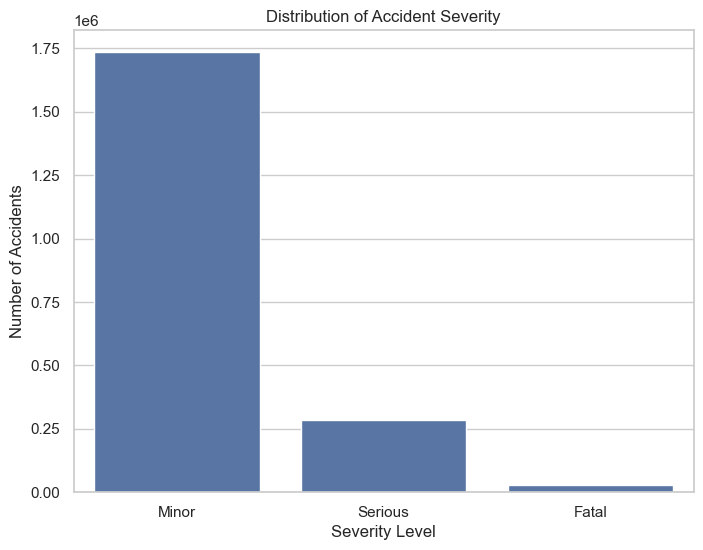


Severity Value Counts (Corrected):
Severity
Minor      1734548
Serious     286339
Fatal        26369
Name: count, dtype: int64


In [2]:
# We will only use features related to road and weather conditions.

# Step 1: Select the specified features and the target variable
features_to_use = {
    'Accident_Severity': 'Severity',
    'Road_Surface_Conditions': 'Road_Conditions',
    'Weather_Conditions': 'Weather',
    'Road_Type': 'Road_Type'
}

df_clean = df[features_to_use.keys()].rename(columns=features_to_use)

# Step 2: Handle missing values
print("Missing values before cleaning:")
print(df_clean.isnull().sum())

# Drop rows with any missing values in our selected columns
df_clean.dropna(inplace=True)

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

# Step 3: Correct the severity labels
# In the 'Severity' column, rename 'Slight' to 'Minor'
df_clean['Severity'] = df_clean['Severity'].replace({'Slight': 'Minor'})

# Define the three classes we want to predict
target_classes = ['Minor', 'Serious', 'Fatal']

# Filter the DataFrame to only include rows with these three classes
df_clean = df_clean[df_clean['Severity'].isin(target_classes)]

print(f"\nShape of cleaned data: {df_clean.shape}")

# Step 4: Visualize the distribution of the target variable
plt.figure(figsize=(8, 6))
sns.countplot(x='Severity', data=df_clean, order=target_classes)
plt.title('Distribution of Accident Severity')
plt.xlabel('Severity Level')
plt.ylabel('Number of Accidents')
plt.show()

print("\nSeverity Value Counts (Corrected):")
print(df_clean['Severity'].value_counts())

In [3]:
# Prepare data for modeling
# Separate features (X) and target (y)
X = df_clean.drop('Severity', axis=1)
y = df_clean['Severity']

# Convert categorical features to numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Encode the target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Features have been one-hot encoded.")
print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y_encoded.shape}")
print(f"Target classes: {le.classes_}")

Features have been one-hot encoded.
Shape of features (X): (2047256, 20)
Shape of target (y): (2047256,)
Target classes: ['Fatal' 'Minor' 'Serious']


In [4]:
# Split the data into training and testing sets
# We use 'stratify' to ensure the class distribution is the same in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Initialize and train the Random Forest Classifier
# Using class_weight='balanced' helps the model handle the imbalanced data
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)

print("Training the model...")
model.fit(X_train, y_train)
print("Model training complete.")

Training the model...
Model training complete.


Classification Report:
              precision    recall  f1-score   support

       Fatal       0.02      0.36      0.03      5274
       Minor       0.88      0.25      0.39    346910
     Serious       0.15      0.54      0.24     57268

    accuracy                           0.29    409452
   macro avg       0.35      0.38      0.22    409452
weighted avg       0.76      0.29      0.36    409452



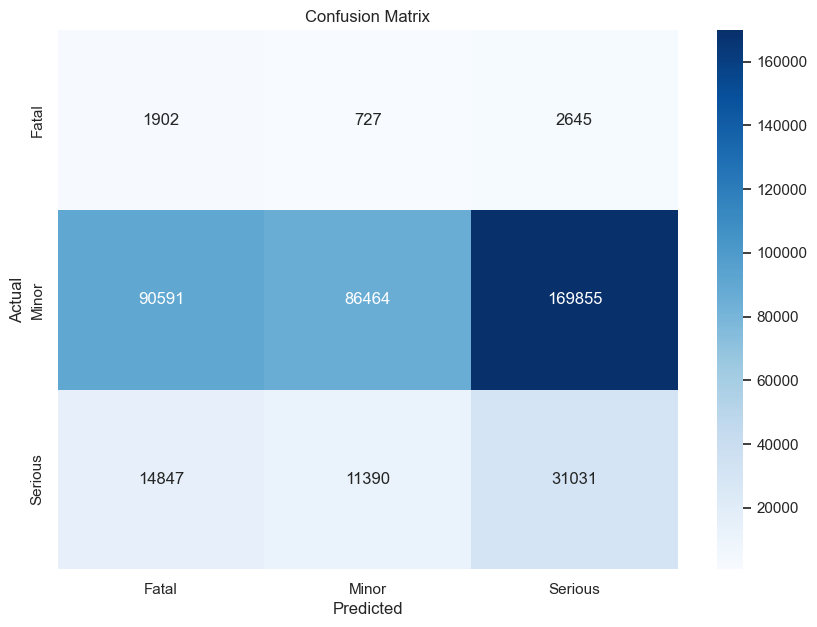

In [5]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()